In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

%matplotlib inline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image, ImageChops, ImageEnhance
from tqdm import tqdm

2025-11-11 22:38:33.072154: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import kagglehub

path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")
print("Path to dataset files:", path)

base_path = os.path.join(path, "real_vs_fake", "real-vs-fake")

/home/tiberiu/Documents/Disertatie/140/ela/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/tiberiu/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2


In [3]:
def ela(image_path, scale=(224, 224), quality=90):
    """
    Performs Error Level Analysis (ELA) on an image and returns a 3-channel RGB result.

    Args:
        image_path (str): Path to the image file.
        scale (tuple): Resize dimensions (width, height).
        quality (int): JPEG quality for recompression.

    Returns:
        np.ndarray: 3-channel ELA image in RGB format (uint8).
    """
    image = Image.open(image_path)
    image = image.resize(scale)

    temp_path = "temp_ela.jpg"
    image.save(temp_path, "JPEG", quality=quality)

    compressed = Image.open(temp_path)

    diff = np.abs(
        np.array(image, dtype=np.int16) - np.array(compressed, dtype=np.int16)
    )
    diff = np.clip(diff * 10, 0, 255).astype(np.uint8)

    return diff


In [4]:
batch_size = 32
img_size = (224, 224)

In [5]:
ela_dir = os.path.join(base_path, "ela_images")
os.makedirs(ela_dir, exist_ok=True)

for stage in ["train", "valid", "test"]:
    stage_dir = os.path.join(base_path, stage)
    os.makedirs(stage_dir, exist_ok=True)

    for category in ["real", "fake"]:
        input_dir = os.path.join(stage_dir, category)
        output_dir = os.path.join(ela_dir, stage, category)

        # if os.path.exists(output_dir) and os.listdir(output_dir):
        #     print(f"Skipping {stage}/{category} (already processed)")
        #     continue

        os.makedirs(output_dir, exist_ok=True)

        for filename in tqdm(
            os.listdir(input_dir), desc=f"Processing {stage}/{category}"
        ):
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                input_path = os.path.join(input_dir, filename)
                output_path = os.path.join(output_dir, filename)
                ela_image = ela(input_path, img_size)
                Image.fromarray(ela_image).save(output_path)

ela_dir = os.path.join(base_path, "ela_images")
train_dir = os.path.join(ela_dir, "train")
val_dir = os.path.join(ela_dir, "valid")
test_dir = os.path.join(ela_dir, "test")

Processing test/fake: 100%|██████████| 10000/10000 [00:33<00:00, 295.11it/s]


In [6]:
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
)

# Load Train Data
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
)

# Load Validation Data
val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
)

# Load Test Data
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False,
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [7]:
def build_model(input_shape=(img_size[0], img_size[1], 3)):
    model = Sequential(
        [
            # Konvolusi pertama
            Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
            MaxPooling2D((2, 2)),
            # Konvolusi kedua
            Conv2D(64, (3, 3), activation="relu"),
            MaxPooling2D((2, 2)),
            # Konvolusi ketiga
            Conv2D(128, (3, 3), activation="relu"),
            MaxPooling2D((2, 2)),
            # Flatten + Fully Connected
            Flatten(),
            Dense(128, activation="relu"),
            Dropout(0.5),
            # Output layer
            Dense(2, activation="softmax"),
        ]
    )
    optimizer = Adam(learning_rate=0.0001)
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model


model = build_model()
model.summary()

/home/tiberiu/Documents/Disertatie/140/ela/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1762894034.768075  169702 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2552 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.utils import plot_model

plot_model(
    model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True
)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [9]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
)

Epoch 1/10


2025-11-11 22:47:16.943077: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f455c00d4a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-11 22:47:16.943107: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti, Compute Capability 7.5
2025-11-11 22:47:17.007417: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-11 22:47:17.243046: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500
2025-11-11 22:47:17.656873: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="

   2/3125 ━━━━━━━━━━━━━━━━━━━━ 3:45 72ms/step - accuracy: 0.5312 - loss: 0.7002 - precision: 0.5312 - recall: 0.5312 

I0000 00:00:1762894042.721096  178858 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6735 - loss: 0.5927 - precision: 0.6735 - recall: 0.6735

2025-11-11 22:51:20.056329: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-11-11 22:51:20.179704: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,109,109]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,111,111]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 284s 89ms/step - accuracy: 0.7405 - loss: 0.5217 - precision: 0.7405 - recall: 0.7405 - val_accuracy: 0.8292 - val_loss: 0.3807 - val_precision: 0.8292 - val_recall: 0.8292
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 266s 85ms/step - accuracy: 0.8340 - loss: 0.3828 - precision: 0.8340 - recall: 0.8340 - val_accuracy: 0.8640 - val_loss: 0.3214 - val_precision: 0.8640 - val_recall: 0.8640
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 263s 84ms/step - accuracy: 0.8622 - loss: 0.3233 - precision: 0.8622 - recall: 0.8622 - val_accuracy: 0.8831 - val_loss: 0.2761 - val_precision: 0.8831 - val_recall: 0.8831
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 264s 85ms/step - accuracy: 0.8840 - loss: 0.2797 - precision: 0.8840 - recall: 0.8840 - val_accuracy: 0.8722 - val_loss: 0.2966 - val_precision: 0.8722 - val_recall: 0.8722
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 248s 79ms/step - accuracy: 0.8994 - loss: 0.2453 - precision: 0.8994 - recall: 0.8994 - val_accuracy: 0.8920 

# Plotting Accuracy and Loss Graph:

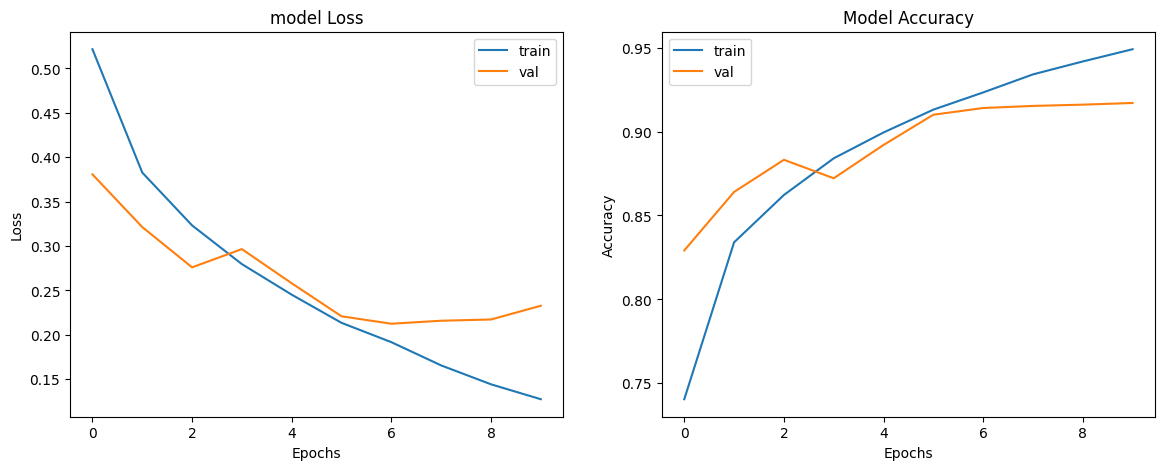

In [10]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["train", "val"])

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["train", "val"])
plt.show()

# Confusion Matrix:

In [11]:
y_pred = model.predict(test_generator)

y_test = test_generator.classes

625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step


In [12]:
y_pred_labels = np.argmax(y_pred, axis=1)

In [13]:
from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(y_test, y_pred_labels)
confusion_matrix

array([[9297,  703],
       [ 978, 9022]])

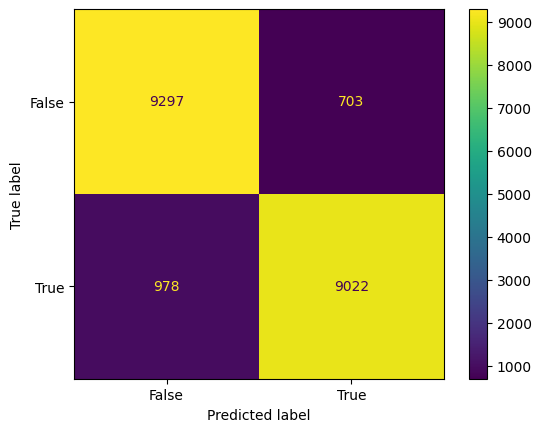

In [14]:
from sklearn import metrics

Fake = False
Real = True
cm_display = metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix, display_labels=[Fake, Real]
)

cm_display.plot()
plt.show()

# ROC AUC Score, Precision Score and Test Accuracy:

In [15]:
print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_pred_labels))
print("AP Score:", metrics.average_precision_score(y_test, y_pred_labels))
print()
print(metrics.classification_report(y_test, y_pred_labels))

ROC AUC Score: 0.9159499999999999
AP Score: 0.8858818406169666

              precision    recall  f1-score   support

           0       0.90      0.93      0.92     10000
           1       0.93      0.90      0.91     10000

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000



In [16]:
_, accu, _, _ = model.evaluate(test_generator)
print("Final Test Acccuracy = {:.3f}".format(accu * 100))

625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.9160 - loss: 0.2480 - precision: 0.9160 - recall: 0.9160
Final Test Acccuracy = 91.595


# Testing for a random image:

In [17]:
from PIL import Image

img_path = os.path.join(ela_dir, "test", "real", "00001.jpg")
ela_image = ela(os.path.join(ela_dir, "test", "real", "00001.jpg"), img_size)
p1 = ela_image.astype(np.float32) / 255.0
p1 = np.expand_dims(p1, axis=0)
p1.shape

(1, 224, 224, 3)

In [18]:
op = np.argmax(model.predict(p1), axis=-1)
print(op)
if op == [0]:
    print("Fake Face")
else:
    print("Real Face")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step
[1]
Real Face
